# Projeto Prático: Machine Learning & Inteligência de Mercado
## Análise Estratégica da Concentração no Comércio Global de Bens Criativos (Dataset OpenFCS)

---

> **Componente Curricular:** Machine Learning aplicado à Administração

> **Instituição:** Curso de Graduação em Administração

> **Objetivo:** Aplicação prática de Ciência de Dados, Machine Learning e Inteligência Artificial Generativa para diagnosticar padrões de concentração e (re)configuração competitiva no comércio mundial de bens criativos, a partir do acervo aberto OpenFCS (UNCTAD, alinhado ao UNESCO Framework for Cultural Statistics 2025).

---

### Corpo Docente & Contato

| Atributo | Detalhes |
| :--- | :--- |
| **Professor** | **Sérgio Assunção Monteiro, D.Sc.** |
| **Conecte-se no LinkedIn** | [🌐 linkedin.com/in/sergio-assunção-monteiro](https://www.linkedin.com/in/sergio-assun%C3%A7%C3%A3o-monteiro-b781897b/) |
| **Currículo Lattes** | [🔬 lattes.cnpq.br/9489191035734025](http://lattes.cnpq.br/9489191035734025) |
| **Repositório GitHub** | [💻 github.com/sergiomonteiro76](https://github.com/sergiomonteiro76) |

---

### Sobre este Notebook
Este ambiente foi configurado para que os alunos atuem como **Analistas de Inteligência de Mercado**. Ao longo do semestre, com apoio de modelos de linguagem (IA) integrados ao ecossistema do Google Colab, vamos reconstruir — do dado bruto ao modelo preditivo — o diagnóstico de estrutura competitiva de um setor econômico real: o comércio internacional de bens criativos.

* **Fonte de dados:** [OpenFCS Dataset](https://doi.org/10.5281/zenodo.21211053) — Monteiro & Dubeux (2026), CC-BY-4.0.
* **Material de apoio:** Capítulos 1 a 3 das notas de aula (Ambiente e primeiro contato; Python/pandas/NumPy; Bases de Dados e SQL).

## Aula 9 — Regressão: Prevendo o Valor Exportado
Hoje treinamos o primeiro modelo supervisionado do curso: regressão linear para prever `log_total` (o log do valor exportado por domínio-ano-economia). Vamos reaproveitar o pipeline do Capítulo 7 sem reescrever nada, adicionar os *clusters* do Capítulo 8 como feature, avaliar com métricas apropriadas, diagnosticar os resíduos e comparar com versões regularizadas (Ridge, Lasso).

**recarregar o acervo — padrão validado**

In [1]:
import requests, zipfile, io, os
import pandas as pd
import numpy as np

url = (
    "https://zenodo.org/records/21211053/files/"
    "openfcs_v1.0.0.zip?download=1"
)
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("openfcs")

endereco = "openfcs/openfcs-1.0.0/data/derived/"
edges = pd.read_csv(endereco + "trade_edges.csv")
edges7 = edges[edges["resolution"] == "cer7"].copy()

print(f"edges7: {len(edges7):,} linhas")   # deve dar 1.026.400

edges7: 1,026,400 linhas


### 9.1 Reconstruindo a tabela de modelagem (Capítulos 7 e 8)
Mesma base: uma linha por domínio-ano-economia, sem o G-77, com `economy_freq` (Capítulo 7).

In [2]:
tabela_ml = (
    edges7.groupby(["fcs_domain", "year", "economy"])["value_usd_millions"]
    .sum()
    .reset_index(name="total_economia")
)
tabela_ml["log_total"] = np.log1p(tabela_ml["total_economia"])

# Remove o G-77 (agregado, nao pais - Capitulos 4 e 7)
tabela_ml = tabela_ml[tabela_ml["economy"] != "G-77 (Group of 77)"].copy()

freq_economia = tabela_ml.groupby("economy")["total_economia"].sum()
tabela_ml["economy_freq"] = tabela_ml["economy"].map(freq_economia)

print(f"tabela_ml: {len(tabela_ml):,} linhas")

tabela_ml: 19,349 linhas


### 9.2 Trazendo o cluster do Capítulo 8 como feature
Uma técnica real e comum: usar a saída de um modelo não supervisionado (o cluster de cada economia) como entrada de um modelo supervisionado.

In [3]:
from sklearn.cluster import KMeans

perfil_total = tabela_ml.pivot_table(
    index="economy",
    columns="fcs_domain",
    values="total_economia",
    aggfunc="sum",
    fill_value=0,
)
perfil_pct = perfil_total.div(perfil_total.sum(axis=1), axis=0)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
perfil_pct["cluster"] = kmeans.fit_predict(perfil_pct).astype(str)

tabela_ml["cluster"] = tabela_ml["economy"].map(perfil_pct["cluster"])
tabela_ml[["economy", "cluster"]].drop_duplicates().head()

,economy,cluster
0,Andorra,1
1,Anguilla,2
2,Argentina,1
3,Armenia,0
4,Australia,3


### 9.3 Divisão temporal e o pipeline do Capítulo 7, expandido
Reaproveitamos o split temporal (não o aleatório) pela mesma razão do Capítulo 7: evitar vazamento. O `ColumnTransformer` ganha uma coluna categórica a mais: `cluster`.

In [4]:
corte = 2020

colunas_x = ["fcs_domain", "year", "economy_freq", "cluster"]
treino = tabela_ml[tabela_ml["year"] < corte]
teste = tabela_ml[tabela_ml["year"] >= corte]

X_treino, y_treino = treino[colunas_x], treino["log_total"]
X_teste, y_teste = teste[colunas_x], teste["log_total"]

print(f"Treino: {len(X_treino):,} linhas | Teste: {len(X_teste):,} linhas")

Treino: 15,266 linhas | Teste: 4,083 linhas


**pipeline de pré-processamento, igual ao Capítulo 7 + cluster**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pre_processador = ColumnTransformer(
    transformers=[
        (
            "categorica",
            OneHotEncoder(handle_unknown="ignore"),
            ["fcs_domain", "cluster"],
        ),
        ("numerica", StandardScaler(), ["year", "economy_freq"]),
    ]
)

### 9.4 Regressão linear múltipla

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline(steps=[
    ("preprocessamento", pre_processador),
    ("modelo", LinearRegression()),
])

modelo_linear.fit(X_treino, y_treino)
y_pred = modelo_linear.predict(X_teste)

print("Modelo treinado.")

Modelo treinado.


### 9.5 Métricas de avaliação
MSE e RMSE penalizam erros grandes com mais força (por causa do quadrado); MAE é mais robusto a outliers; R² mede a fração de variância explicada; R² ajustado penaliza o uso de muitas variáveis.

In [7]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

n = len(y_teste)
p = X_teste.shape[1]

mse = mean_squared_error(y_teste, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_teste, y_pred)
r2 = r2_score(y_teste, y_pred)
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE:         {mse:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"R2:          {r2:.4f}")
print(f"R2 ajustado: {r2_ajustado:.4f}")

MSE:         4.8758
RMSE:        2.2081
MAE:         1.8153
R2:          0.3737
R2 ajustado: 0.3731


### 9.6 Um comparativo: e um modelo ingênuo?
Antes de comemorar o R², vale checar contra a referência mais simples possível: sempre prever a média do treino.

In [8]:
media_treino = y_treino.mean()
y_pred_baseline = np.full_like(y_teste, media_treino)

mse_baseline = mean_squared_error(y_teste, y_pred_baseline)
print(f"MSE do modelo ingenuo (sempre a media): {mse_baseline:.4f}")
print(f"MSE do modelo linear:                   {mse:.4f}")
print(f"Reducao de erro: {(1 - mse/mse_baseline):.1%}")

MSE do modelo ingenuo (sempre a media): 7.8110
MSE do modelo linear:                   4.8758
Reducao de erro: 37.6%


### 9.7 Análise de resíduos
Um bom modelo linear tem resíduos sem padrão visível (dispersos ao redor de zero) e aproximadamente normais.

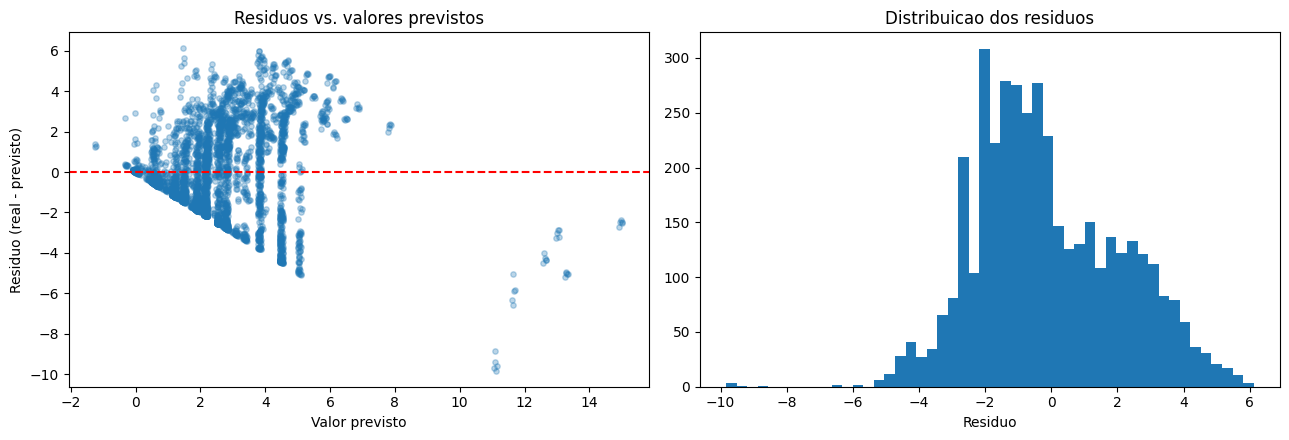

Media dos residuos: -0.1224
Desvio-padrao:      2.2050


In [9]:
import matplotlib.pyplot as plt

residuos = y_teste - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred, residuos, alpha=0.3, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valor previsto")
axes[0].set_ylabel("Residuo (real - previsto)")
axes[0].set_title("Residuos vs. valores previstos")

axes[1].hist(residuos, bins=50)
axes[1].set_xlabel("Residuo")
axes[1].set_title("Distribuicao dos residuos")

plt.tight_layout()
plt.show()

print(f"Media dos residuos: {residuos.mean():.4f}")
print(f"Desvio-padrao:      {residuos.std():.4f}")

### 9.8 Interpretando os coeficientes

In [10]:
nomes_features = modelo_linear.named_steps[
    "preprocessamento"
].get_feature_names_out()
coeficientes = modelo_linear.named_steps["modelo"].coef_

tabela_coef = pd.DataFrame({
    "feature": nomes_features,
    "coeficiente": coeficientes,
}).sort_values("coeficiente", ascending=False)

tabela_coef

,feature,coeficiente
2,categorica__fcs_domain_C. Visual arts (crafts)...,2.190824
7,categorica__cluster_1,1.196782
11,numerica__economy_freq,1.025549
9,categorica__cluster_3,0.634364
3,categorica__fcs_domain_D. Books and press,0.510059
4,categorica__fcs_domain_E. Audiovisual and inte...,0.249216
10,numerica__year,0.123924
6,categorica__cluster_0,-0.030387
1,categorica__fcs_domain_B. Performance and cele...,-0.152133
0,categorica__fcs_domain_A. Cultural and natural...,-1.121152


### 9.9 Regularização: Ridge e Lasso
Ridge encolhe coeficientes em direção a zero sem zerá-los; Lasso pode zerar coeficientes por completo — uma forma automática de seleção de variáveis.

In [11]:
from sklearn.linear_model import Ridge, Lasso

modelo_ridge = Pipeline(steps=[
    ("preprocessamento", pre_processador),
    ("modelo", Ridge(alpha=1.0)),
])
modelo_lasso = Pipeline(steps=[
    ("preprocessamento", pre_processador),
    ("modelo", Lasso(alpha=0.01)),
])

modelo_ridge.fit(X_treino, y_treino)
modelo_lasso.fit(X_treino, y_treino)

pred_ridge = modelo_ridge.predict(X_teste)
pred_lasso = modelo_lasso.predict(X_teste)

print(f"R2 Linear: {r2_score(y_teste, y_pred):.4f}")
print(f"R2 Ridge:  {r2_score(y_teste, pred_ridge):.4f}")
print(f"R2 Lasso:  {r2_score(y_teste, pred_lasso):.4f}")

R2 Linear: 0.3737
R2 Ridge:  0.3737
R2 Lasso:  0.3718


**comparando coeficientes lado a lado**

In [12]:
coef_comparados = pd.DataFrame({
    "feature": nomes_features,
    "linear": modelo_linear.named_steps["modelo"].coef_,
    "ridge": modelo_ridge.named_steps["modelo"].coef_,
    "lasso": modelo_lasso.named_steps["modelo"].coef_,
})
coef_comparados["lasso_zerou"] = coef_comparados["lasso"] == 0
coef_comparados.sort_values("linear", ascending=False)

,feature,linear,ridge,lasso,lasso_zerou
2,categorica__fcs_domain_C. Visual arts (crafts)...,2.190824,2.189940,2.013871,False
7,categorica__cluster_1,1.196782,1.193859,0.514929,False
11,numerica__economy_freq,1.025549,1.025493,1.015518,False
9,categorica__cluster_3,0.634364,0.631907,0.000000,True
3,categorica__fcs_domain_D. Books and press,0.510059,0.509720,0.331491,False
4,categorica__fcs_domain_E. Audiovisual and inte...,0.249216,0.249047,0.072546,False
10,numerica__year,0.123924,0.123919,0.114077,False
6,categorica__cluster_0,-0.030387,-0.032688,-0.611036,False
1,categorica__fcs_domain_B. Performance and cele...,-0.152133,-0.152282,-0.229695,False
0,categorica__fcs_domain_A. Cultural and natural...,-1.121152,-1.120626,-1.159075,False


### 9.10 Escolhendo alpha com validação cruzada

In [13]:
from sklearn.linear_model import RidgeCV, LassoCV

alphas_testados = np.logspace(-3, 2, 20)

modelo_ridge_cv = Pipeline(steps=[
    ("preprocessamento", pre_processador),
    ("modelo", RidgeCV(alphas=alphas_testados, cv=5)),
])
modelo_ridge_cv.fit(X_treino, y_treino)

alpha_escolhido = modelo_ridge_cv.named_steps["modelo"].alpha_
print(f"Melhor alpha (RidgeCV): {alpha_escolhido:.4f}")

pred_ridge_cv = modelo_ridge_cv.predict(X_teste)
print(f"R2 RidgeCV no teste:    {r2_score(y_teste, pred_ridge_cv):.4f}")

Melhor alpha (RidgeCV): 29.7635
R2 RidgeCV no teste:    0.3732


### 9.11 Comparativo final

In [14]:
def metricas(y_real, y_prev, nome):
    return {
        "modelo": nome,
        "MSE": mean_squared_error(y_real, y_prev),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_prev)),
        "MAE": mean_absolute_error(y_real, y_prev),
        "R2": r2_score(y_real, y_prev),
    }

resultados = pd.DataFrame([
    metricas(y_teste, y_pred_baseline, "Baseline (media)"),
    metricas(y_teste, y_pred, "Linear"),
    metricas(y_teste, pred_ridge, "Ridge (alpha=1.0)"),
    metricas(y_teste, pred_lasso, "Lasso (alpha=0.01)"),
    metricas(y_teste, pred_ridge_cv, "RidgeCV"),
])
resultados.sort_values("R2", ascending=False)

,modelo,MSE,RMSE,MAE,R2
1,Linear,4.875828,2.208128,1.815258,0.373666
2,Ridge (alpha=1.0),4.875938,2.208153,1.815342,0.373652
4,RidgeCV,4.879842,2.209036,1.817994,0.373150
3,Lasso (alpha=0.01),4.890371,2.211418,1.826094,0.371798
0,Baseline (media),7.811045,2.794825,2.328687,-0.003383


## 🧪 Exercícios Práticos — Aula 9

> **Como usar:** resolva cada exercício em uma célula de código abaixo do enunciado. Depois, leve o resultado para uma IA usando o *prompt sugerido*.

---

### Exercício 1 — Quanto o modelo melhora sobre o ingênuo?
**📝 Tarefa:** Usando a Célula 15, calcule também a redução percentual de RMSE (não só MSE) do modelo linear sobre o baseline. Esse ganho parece grande o suficiente para justificar o uso do modelo em produção?

**🤖 Pergunte à IA:**
> "Meu modelo reduziu o MSE em [X]% em relação a um baseline que sempre prevê a média. Isso é considerado uma boa melhora em problemas de previsão de valores econômicos, ou o padrão do setor costuma ser mais exigente?"

---

### Exercício 2 — `economy` direto vs. `economy_freq`
**📝 Tarefa:** Repita o pipeline usando `OneHotEncoder` em `economy` diretamente (em vez de `economy_freq`), como sugerido no Exercício 5 do Capítulo 7. O R² melhora? O modelo fica mais lento?

**🤖 Pergunte à IA:**
> "Troquei uma feature de frequência por one-hot de alta cardinalidade em um modelo de regressão linear. O R² foi de [X] para [Y]. Por que um R² mais alto com one-hot de alta cardinalidade não é necessariamente uma vitória?"

---

### Exercício 3 — Previsto vs. real
**📝 Tarefa:** Crie um gráfico de dispersão com `y_teste` no eixo X e `y_pred` no eixo Y, mais uma linha diagonal de referência ($y=x$). Em que faixa de valores o modelo erra mais?

**🤖 Pergunte à IA:**
> "Meu gráfico de valores previstos vs. reais mostra [descreva o padrão — ex.: dispersão maior em valores altos]. O que esse padrão sugere sobre onde o modelo é mais confiável?"

---

### Exercício 4 — Regularização extrema
**📝 Tarefa:** Rode o Ridge com `alpha=1000` e o Lasso com `alpha=1.0`. O que acontece com os coeficientes nos dois casos? Algum vira, na prática, um "modelo que só prevê a média"?

**🤖 Pergunte à IA:**
> "Ao aumentar drasticamente o alpha do Ridge e do Lasso, meus coeficientes ficaram [descreva]. Por que um alpha muito alto tende a aproximar qualquer modelo regularizado de um modelo baseline?"

---

### Exercício 5 — O modelo erra igual em todos os clusters?
**📝 Tarefa:** Calcule o erro médio absoluto (MAE) separadamente para cada valor de `cluster` (Capítulo 8) no conjunto de teste. O modelo é igualmente preciso nos quatro grupos?

**🤖 Pergunte à IA:**
> "O erro médio absoluto do meu modelo por cluster foi: [cole os valores]. Se um cluster tem erro bem mais alto que os outros, que hipóteses eu deveria investigar antes de concluir que o modelo está ruim?"